# Gradient boosting

## Why ensembles?

A single decision tree (see earlier notebook) tends to overfit: it has high *variance*, meaning small changes in the training data can produce a very different tree. *Ensemble methods* combine many trees to produce predictions that are more accurate and more stable than any individual tree. Gradient boosting is the classic *boosting* strategy; a companion notebook covers the other major strategy, *bagging* (random forests).

## Gradient boosting

Gradient boosting builds trees *sequentially*, where each new tree is trained to correct the errors (residuals) of the ensemble built so far. The ensemble after $m$ trees is

$$
F_m(\boldsymbol{x}) = F_{m-1}(\boldsymbol{x}) + \eta \, h_m(\boldsymbol{x})
$$

where $h_m$ is a new, typically shallow tree fitted to the negative gradient of the loss function with respect to $F_{m-1}$ (the residuals, in the case of squared-error loss), and $\eta$ is a small *learning rate* that controls how much each new tree is allowed to contribute. Unlike bagging, boosting reduces *bias*: individual trees are deliberately kept weak (shallow), and the ensemble gradually becomes more expressive as trees are added — which also means that, unlike a random forest, adding too many trees can eventually overfit.

## Library imports

In [1]:
import matplotlib.pyplot as plt
import sklearn


## Data preparation

We reuse the breast cancer data set from the decision tree notebook.

In [2]:
cancer = sklearn.datasets.load_breast_cancer()
X, y = cancer["data"], cancer["target"]

X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=0,
)


## Model definition and training

We build a sequential ensemble of 200 shallow trees, Eq. (1), each trained to correct the remaining errors, with a small learning rate $\eta$.

In [3]:
gb = sklearn.ensemble.GradientBoostingClassifier(
    n_estimators=200,
    max_depth=2,
    learning_rate=0.1,
    random_state=0,
)

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)
print(sklearn.metrics.classification_report(y_test, y_pred_gb, target_names=cancer["target_names"]))


              precision    recall  f1-score   support

   malignant       0.89      0.95      0.92        42
      benign       0.97      0.93      0.95        72

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114



## Effect of ensemble size: staged predictions

Because boosting adds trees sequentially, `sklearn` lets us inspect the ensemble's error after every stage using `staged_predict`, without refitting. This shows both the bias-reducing benefit of adding trees and the overfitting risk mentioned above: training error keeps dropping, while test error eventually flattens (and can even start creeping up) as more trees are added.

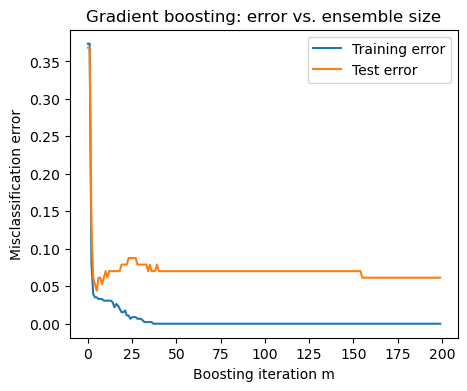

In [4]:
train_errors, test_errors = [], []

for y_pred_train, y_pred_test in zip(gb.staged_predict(X_train), gb.staged_predict(X_test)):
    train_errors.append(1 - sklearn.metrics.accuracy_score(y_train, y_pred_train))
    test_errors.append(1 - sklearn.metrics.accuracy_score(y_test, y_pred_test))

plt.figure(figsize=(5, 4))
plt.plot(train_errors, label="Training error")
plt.plot(test_errors, label="Test error")
plt.xlabel("Boosting iteration m")
plt.ylabel("Misclassification error")
plt.title("Gradient boosting: error vs. ensemble size")
plt.legend()
plt.show()


## Comparing a single tree to gradient boosting

To highlight the effect of boosting, we also fit a single decision tree of comparable depth and compare test accuracy.

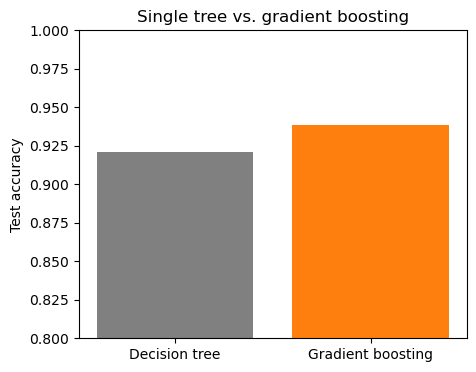

In [5]:
tree = sklearn.tree.DecisionTreeClassifier(max_depth=3, random_state=0)
tree.fit(X_train, y_train)

models = {
    "Decision tree": tree,
    "Gradient boosting": gb,
}
accuracies = {name: sklearn.metrics.accuracy_score(y_test, m.predict(X_test)) for name, m in models.items()}

plt.figure(figsize=(5, 4))
plt.bar(accuracies.keys(), accuracies.values(), color=["gray", "tab:orange"])
plt.ylabel("Test accuracy")
plt.ylim(0.8, 1.0)
plt.title("Single tree vs. gradient boosting")
plt.show()


## Model evaluation

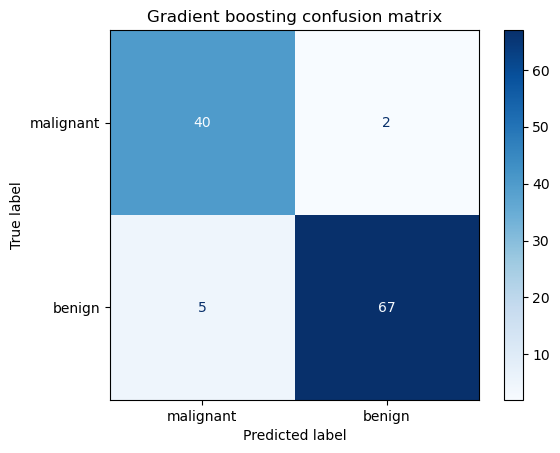

In [6]:
cm = sklearn.metrics.confusion_matrix(y_test, y_pred_gb)
disp = sklearn.metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=cancer["target_names"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Gradient boosting confusion matrix")
plt.show()


## Feature importance

As with a single tree, the ensemble provides an aggregated feature importance, averaged over all 200 trees.

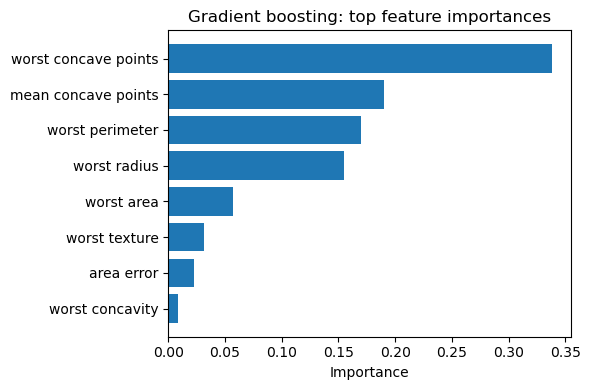

In [7]:
importances = gb.feature_importances_
order = importances.argsort()[::-1][:8]

plt.figure(figsize=(6, 4))
plt.barh(
    [cancer["feature_names"][i] for i in order][::-1],
    importances[order][::-1],
)
plt.xlabel("Importance")
plt.title("Gradient boosting: top feature importances")
plt.tight_layout()
plt.show()


## Take-away

Gradient boosting (and optimized implementations such as XGBoost or LightGBM) tends to achieve the best raw predictive performance on tabular data among tree-based methods, at the cost of more careful tuning of `n_estimators`, `max_depth`, and `learning_rate` to avoid overfitting — unlike a random forest (companion notebook), simply adding more trees is not always safe. In practice it is common to start with a random forest as a robust baseline and move to gradient boosting once there is time and validation data available to tune it properly.